# People ID — **voting** (simple track)

A **short, linear** notebook in the spirit of `face_classi.ipynb`: one path through the pipeline, heavy comments, no zip/metadata machinery.

**Matcher:** gallery rows **vote** if **cosine distance** ≤ `MATCH_THRESHOLD`. An identity remains a **candidate** only if it has **≥ `MIN_VOTES`** votes, its **mean** voting distance is **≤ `MEAN_VOTE_DIST_MAX`**, and its **best** voting distance (min over its voting rows) is **≤ `MIN_BEST_VOTE_DIST_MAX`**. Among the survivors, the winner is the identity with the **lowest mean distance** over its voting rows. Tie-break: lower minimum distance among voting rows, then higher vote count.

**§6** runs the **same** pipeline on scenes in `photos_all/` (by default the **first `EVAL_MAX_SCENES`** for quick tests; set to `None` for all files), reads **ground truth** from the filename token (before the first `_`), and reports **TP / FP / FN**, **precision**, and **recall** per scene. Extra accepted identities not in the token count as **FP**; rejected / unknown faces do not. **§5** is only the CD visualization demo.

## 0) Setup

Use your project **venv** (`requirements.txt`: `deepface`, `opencv-python`, `matplotlib`, `pandas`, `tqdm`, TensorFlow stack). Uncomment installs only in a fresh environment.

In [15]:
# !pip install deepface opencv-python matplotlib pandas tqdm tensorflow tf-keras

%matplotlib inline

import os

# Quiet TensorFlow C++ logs (optional).
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load TensorFlow before DeepFace so we can turn off Keras progress bars (MTCNN uses model.predict).
import tensorflow as tf

tf.keras.utils.disable_interactive_logging()

from deepface import DeepFace
from tqdm.auto import tqdm

print("OK: imports (Keras inference progress bars disabled)")

OK: imports (Keras inference progress bars disabled)


## 1) Paths & hyperparameters

**Task 1 (data):** we only assume `open_data_set/` exists with `photos_all_faces/` (gallery) and `photos_all/` (scenes), same naming as the wild notebooks (`a_gp_....jpg` → identity **A**).

In [16]:
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "open_data_set"
GALLERY_DIR = DATASET_ROOT / "photos_all_faces"

# Recognition model for DeepFace.represent (gallery + crops are already faces → detector_backend="skip").
MODEL_NAME = "Facenet512"  # "VGG-Face", "Facenet", "OpenFace", "DeepFace", "DeepID", "ArcFace"

# MTCNN for scene images only (section 6.4 style in the wild notebook — no extra NMS).
DETECTOR_BACKEND = "mtcnn"  # "opencv", "ssd", "dlib", "mtcnn", "retinaface", "mediapipe"

# Voting matcher (tune together).
MATCH_THRESHOLD = 0.55    # gallery row votes if cosine_distance(probe, row) <= this
MIN_VOTES = 20            # identity needs at least this many votes to be a candidate

# Candidate filters after the vote floor.
MEAN_VOTE_DIST_MAX = 0.48     # candidate's mean voting distance must be <= this (stricter than vote threshold)
MIN_BEST_VOTE_DIST_MAX = 0.37 # candidate's best (min) voting distance must be <= this

# Scene folder: filename token before first `_` is ground truth (e.g. `cd_gp_...` → {C,D}).
SCENES_DIR = DATASET_ROOT / "photos_all"

# Demo / CD scene for §5 plots only.
TEST_SCENE = DATASET_ROOT / "photos_all" / "cd_gp_0_eo_12.JPG"

def list_images(folder: Path):
    out = []
    if not folder.is_dir():
        return out
    for pat in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
        out.extend(folder.glob(pat))
    return sorted(out)


def infer_identity(path: Path) -> str:
    return path.stem.split("_")[0].upper()


def token_to_expected_ids(token: str):
    """e.g. 'CD' -> {'C','D'}"""
    return set(list(token.upper()))


def cosine_distance(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> float:
    """1 - cosine_similarity (same as wild voting notebook)."""
    a_norm = np.linalg.norm(a) + eps
    b_norm = np.linalg.norm(b) + eps
    return float(1.0 - np.dot(a, b) / (a_norm * b_norm))


print("Gallery dir:", GALLERY_DIR)
print("Scenes dir:", SCENES_DIR)
print("Test scene (§5 demo):", TEST_SCENE)


Gallery dir: /Users/shamiul/Documents/GitHub/AI-Computer-Vision-Project/open_data_set/photos_all_faces
Scenes dir: /Users/shamiul/Documents/GitHub/AI-Computer-Vision-Project/open_data_set/photos_all
Test scene (§5 demo): /Users/shamiul/Documents/GitHub/AI-Computer-Vision-Project/open_data_set/photos_all/cd_gp_0_eo_12.JPG


## 2) Gallery table (paths only)

One row per image: `path`, `identity`.

In [17]:
paths = list_images(GALLERY_DIR)
if not paths:
    raise FileNotFoundError(f"No images in {GALLERY_DIR}")

gallery_paths = pd.DataFrame(
    [{"path": str(p.resolve()), "identity": infer_identity(p)} for p in paths]
)
print(len(gallery_paths), "gallery images")
display(gallery_paths["identity"].value_counts().to_frame("n"))

1364 gallery images


,n
identity,
A,124
B,124
C,124
D,124
E,124
F,124
G,124
H,124
I,124


## 3) Gallery embeddings

**Task 2.3** (gallery side): `DeepFace.represent` with **`detector_backend="skip"`** because files in `photos_all_faces` are already tight crops.

In [18]:
_min_per_id = gallery_paths.groupby("identity").size().min()
if MIN_VOTES > _min_per_id:
    print(
        f"WARNING: MIN_VOTES={MIN_VOTES} but some ID has only {_min_per_id} images. "
        "Lower MIN_VOTES for this demo or the matcher will often reject."
    )

embeddings = []
for _, row in tqdm(gallery_paths.iterrows(), total=len(gallery_paths), desc="Gallery embed"):
    try:
        rep = DeepFace.represent(
            img_path=row["path"],
            model_name=MODEL_NAME,
            detector_backend="skip",
            enforce_detection=False,
        )
        embeddings.append(np.array(rep[0]["embedding"], dtype=np.float32))
    except Exception:
        embeddings.append(None)

gallery_df = gallery_paths.assign(embedding=embeddings).dropna(subset=["embedding"]).reset_index(drop=True)
print("Rows with embeddings:", len(gallery_df))

Gallery embed: 100%|██████████| 1364/1364 [03:38<00:00,  6.25it/s]

Rows with embeddings: 1364


## 4) Vote filter + candidate mean/min gates

**Tasks 2.5 & 2.6:** rows under `MATCH_THRESHOLD` vote per identity. A candidate must pass **all** of: `MIN_VOTES`, `mean_vote_d <= MEAN_VOTE_DIST_MAX`, and `min_vote_d <= MIN_BEST_VOTE_DIST_MAX`. Winner = **minimum mean distance** over the surviving candidates’ voting rows (tie-break: min distance in that set, then vote count).

In [19]:
def format_votes_by_id(votes_by_id: dict) -> str:
    """Pretty string: A:0, B:101, C:1 ... (every gallery identity, sorted)."""
    return ", ".join(f"{k}:{votes_by_id[k]}" for k in sorted(votes_by_id.keys()))


def match_gallery_vote_max(gallery_df: pd.DataFrame, probe_emb: np.ndarray) -> dict:
    """Vote if dist <= T; candidate must pass vote floor, mean-vote cap, and min-vote cap; then pick min mean-vote dist."""
    dists = gallery_df["embedding"].apply(lambda e: cosine_distance(probe_emb, e))
    g = gallery_df.assign(_d=dists)
    under = g["_d"] <= MATCH_THRESHOLD
    all_ids_sorted = sorted(gallery_df["identity"].unique())

    def _empty_votes():
        return {i: 0 for i in all_ids_sorted}

    def _diag_row(votes_by_id: dict):
        j = int(dists.idxmin())
        return {
            "predicted_id": None,
            "accepted": False,
            "vote_count": 0,
            "runner_up_id": None,
            "second_best_count": 0,
            "nearest_distance": float(dists.loc[j]),
            "min_dist_global": float(dists.min()),
            "min_dist_among_votes": None,
            "gallery_path": g.loc[j, "path"],
            "votes_by_id": votes_by_id,
        }

    if under.sum() == 0:
        return _diag_row(_empty_votes())

    vc = g.loc[under].groupby("identity").size()
    votes_by_id = {i: int(vc.get(i, 0)) for i in all_ids_sorted}
    by_votes = vc[vc >= MIN_VOTES]
    if len(by_votes) == 0:
        out = _diag_row(votes_by_id)
        out["vote_count"] = int(vc.max()) if len(vc) else 0
        return out

    def _vote_dists(ident):
        return g.loc[under & (g["identity"] == ident), "_d"]

    def _mean_vote_dist(ident):
        return float(_vote_dists(ident).mean())

    def _min_vote_dist(ident):
        return float(_vote_dists(ident).min())

    cand_ids = [
        ident
        for ident in by_votes.index
        if _mean_vote_dist(ident) <= MEAN_VOTE_DIST_MAX and _min_vote_dist(ident) <= MIN_BEST_VOTE_DIST_MAX
    ]
    if len(cand_ids) == 0:
        # Everyone with enough votes fails mean/min gates: report the vote leader's *true*
        # mean/min over voting rows (do not use global idxmin — that mislabels "mean_vote_d").
        vote_leader = min(
            by_votes.index,
            key=lambda ident: (
                -int(by_votes[ident]),
                _mean_vote_dist(ident),
                _min_vote_dist(ident),
            ),
        )
        sub_vote = _vote_dists(vote_leader)
        j_best = int(sub_vote.idxmin())
        mean_v = float(sub_vote.mean())
        min_v = float(sub_vote.min())
        return {
            "predicted_id": None,
            "accepted": False,
            "vote_count": int(by_votes[vote_leader]),
            "runner_up_id": None,
            "second_best_count": 0,
            "nearest_distance": mean_v,
            "min_dist_global": float(dists.min()),
            "min_dist_among_votes": min_v,
            "gallery_path": g.loc[j_best, "path"],
            "votes_by_id": votes_by_id,
            "votes_leader_id": vote_leader,
        }

    pred_id = min(
        cand_ids,
        key=lambda ident: (
            _mean_vote_dist(ident),
            _min_vote_dist(ident),
            -int(by_votes[ident]),
        ),
    )

    sub_vote = _vote_dists(pred_id)
    sub_all = g[g["identity"] == pred_id]
    j_best = int(sub_vote.idxmin())
    mean_vote_d = float(sub_vote.mean())
    min_among_votes = float(sub_vote.min())

    others = [i for i in cand_ids if i != pred_id]
    runner_up_id = None
    second_best_count = 0
    if len(others) > 0:
        ru = min(
            others,
            key=lambda ident: (
                _mean_vote_dist(ident),
                _min_vote_dist(ident),
                -int(by_votes[ident]),
            ),
        )
        runner_up_id = ru
        second_best_count = int(by_votes[ru])

    return {
        "predicted_id": pred_id,
        "accepted": True,
        "vote_count": int(by_votes[pred_id]),
        "runner_up_id": runner_up_id,
        "second_best_count": second_best_count,
        "nearest_distance": mean_vote_d,
        "min_dist_global": float(dists.min()),
        "min_dist_among_votes": min_among_votes,
        "gallery_path": g.loc[j_best, "path"],
        "votes_by_id": votes_by_id,
    }


def item_to_box_and_crop(item, scene_bgr, h0, w0):
    a = item["facial_area"]
    x = max(0, min(int(a["x"]), w0 - 1))
    y = max(0, min(int(a["y"]), h0 - 1))
    w = max(1, min(int(a["w"]), w0 - x))
    h = max(1, min(int(a["h"]), h0 - y))
    if w < 10 or h < 10:
        return None
    b = {"x": x, "y": y, "w": w, "h": h}
    face_arr = item.get("face")
    if face_arr is not None:
        fa = np.asarray(face_arr)
        if fa.dtype != np.uint8:
            fa = np.clip(fa * 255.0, 0, 255).astype(np.uint8)
        crop_rgb = fa[:, :, :3]
    else:
        crop_bgr = scene_bgr[b["y"] : b["y"] + b["h"], b["x"] : b["x"] + b["w"]]
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    return b, crop_rgb


def scene_bgr_to_face_rows(scene_bgr: np.ndarray, gallery_df: pd.DataFrame) -> list:
    """MTCNN → valid crops → ArcFace embeddings → match_gallery_vote_max (same as §5)."""
    h0, w0 = scene_bgr.shape[:2]
    try:
        raw_faces = DeepFace.extract_faces(
            img_path=scene_bgr,
            detector_backend=DETECTOR_BACKEND,
            enforce_detection=True,
            align=True,
        )
    except Exception:
        raw_faces = []
    items_ok = []
    for item in raw_faces:
        pair = item_to_box_and_crop(item, scene_bgr, h0, w0)
        if pair is not None:
            items_ok.append(pair)
    face_rows = []
    for b, crop_rgb in items_ok:
        rep = DeepFace.represent(
            img_path=crop_rgb,
            model_name=MODEL_NAME,
            detector_backend="skip",
            enforce_detection=False,
        )
        emb = np.array(rep[0]["embedding"], dtype=np.float32)
        m = match_gallery_vote_max(gallery_df, emb)
        face_rows.append({"box": b, "crop_rgb": crop_rgb, "m": m})
    return face_rows


print("match_gallery_vote_max, item_to_box_and_crop, scene_bgr_to_face_rows defined.")


match_gallery_vote_max, item_to_box_and_crop, scene_bgr_to_face_rows defined.


## 5) CD scene demo — one MTCNN pass

**Tasks 2.1–2.4 & 2.7:** `extract_faces` (**MTCNN**) once on `cd_gp_0_eo_12.JPG`. From the **same** detections we build **`query_embedding`** (**Task 2.4**, face `QUERY_FACE_INDEX`), then process **every** face: crop → `represent` → **`match_gallery_vote_max`** (vote filter, then **min mean** distance among candidates). Scene overview + **N×2** crop ‖ gallery panels (with full vote tallies).

There is **no** second MTCNN run — this replaces the old separate §5 / §6 split.

cd_gp_0_eo_12.JPG expected token IDs: ['C', 'D']
Task 2.4  query_embedding shape: (512,) | scene face index: 0
  vs gallery row 0 id=A  dist=0.9921
  vs gallery row 1 id=A  dist=0.9181
  vs gallery row 2 id=A  dist=0.9344
  vs gallery row 3 id=A  dist=0.9168
  vs gallery row 4 id=A  dist=0.9642
Task 2.4  votes (dist <= T): A:56, B:1, C:0, D:0, E:5, F:0, G:0, H:0, I:0, J:44, K:28

Face 0: pred=---  accepted=False  winner_votes=56  mean_vote_d=0.4934  min_vote_d=0.4067
  all votes: A:56, B:1, C:0, D:0, E:5, F:0, G:0, H:0, I:0, J:44, K:28
Face 1: pred=J  accepted=True  winner_votes=87  mean_vote_d=0.3375  min_vote_d=0.2312
  all votes: A:45, B:53, C:1, D:0, E:17, F:3, G:0, H:0, I:1, J:87, K:42
Face 2: pred=D  accepted=True  winner_votes=84  mean_vote_d=0.4707  min_vote_d=0.3381
  all votes: A:20, B:2, C:0, D:84, E:0, F:0, G:0, H:0, I:0, J:0, K:0
Face 3: pred=C  accepted=True  winner_votes=23  mean_vote_d=0.4788  min_vote_d=0.3369
  all votes: A:0, B:6, C:23, D:0, E:8, F:4, G:13, H:4, I:3,

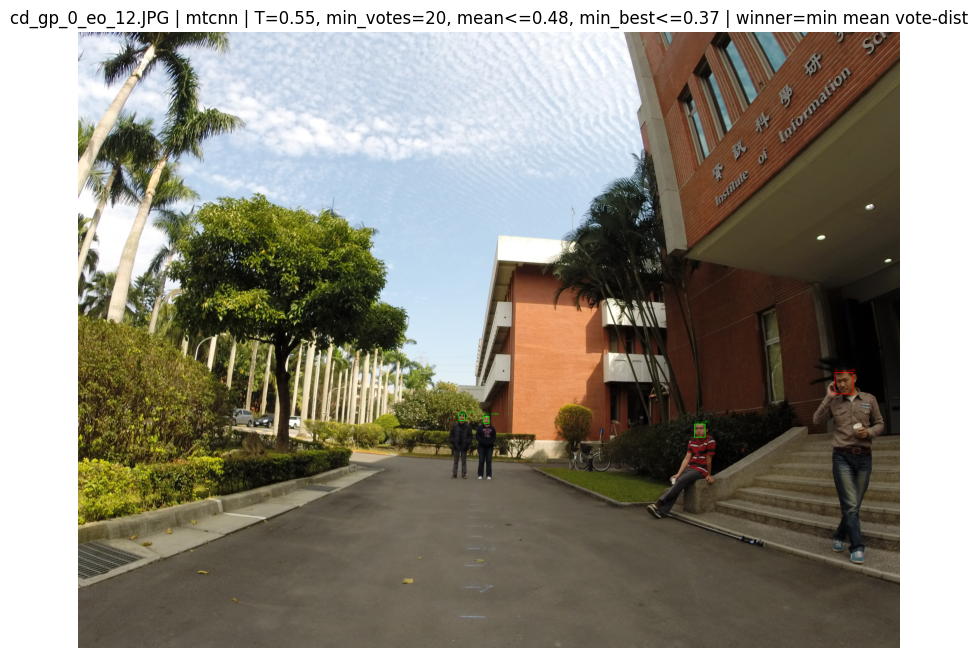

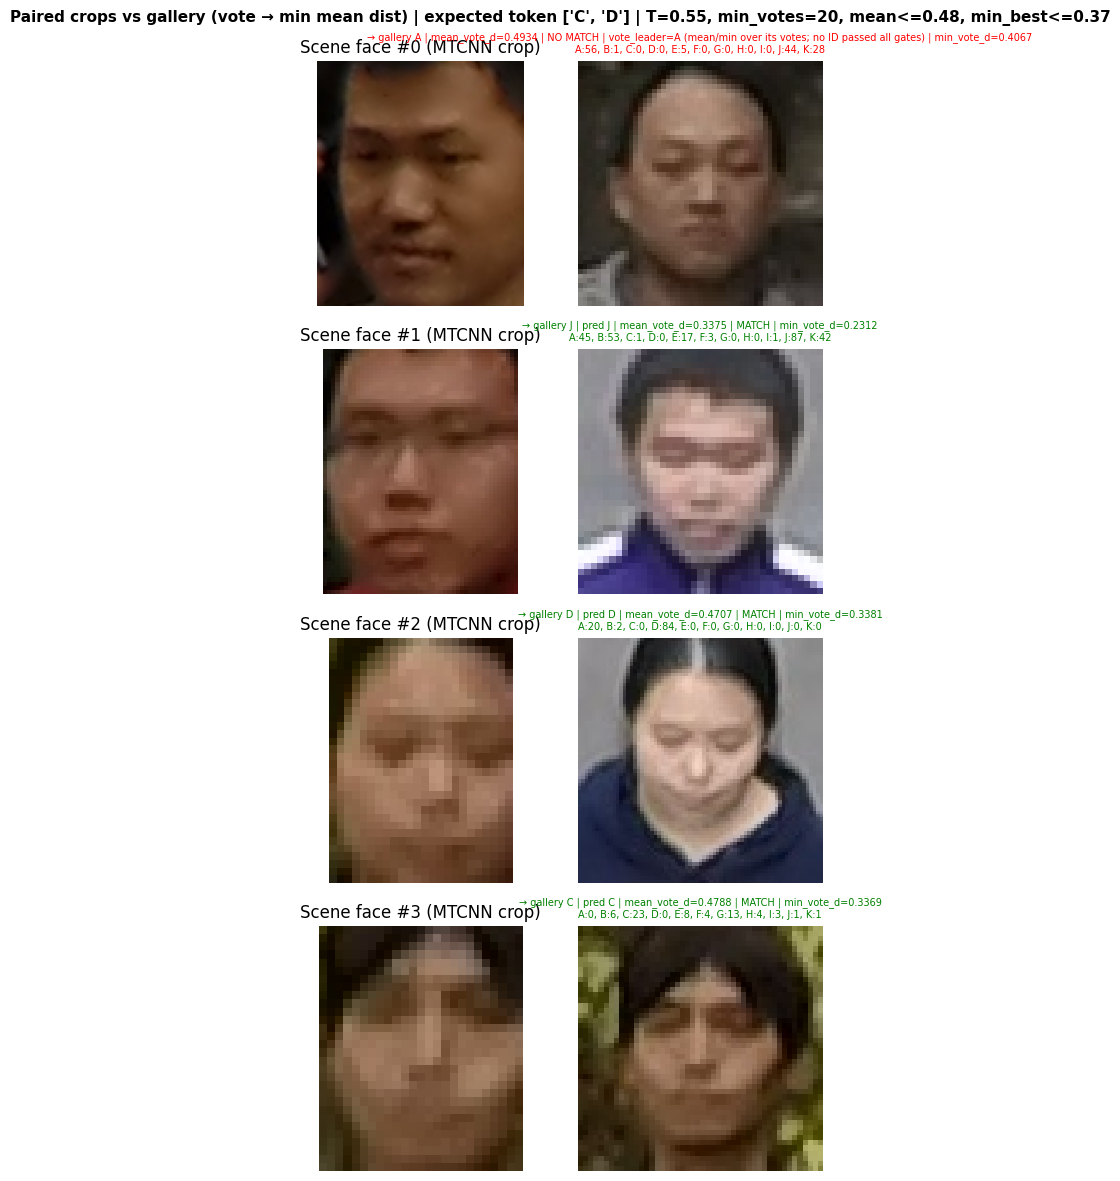

In [20]:
QUERY_FACE_INDEX = 0  # Task 2.4: which detected face (after size filter) becomes `query_embedding`

scene_bgr = cv2.imread(str(TEST_SCENE))
if scene_bgr is None:
    raise FileNotFoundError(TEST_SCENE)

token = Path(TEST_SCENE).stem.split("_")[0].upper()
expected_ids = token_to_expected_ids(token)
print(TEST_SCENE.name, "expected token IDs:", sorted(expected_ids))

face_rows = scene_bgr_to_face_rows(scene_bgr, gallery_df)
items_ok = [(fr["box"], fr["crop_rgb"]) for fr in face_rows]

if len(items_ok) <= QUERY_FACE_INDEX:
    raise RuntimeError(
        f"Task 2.4 / demo: need face at index {QUERY_FACE_INDEX}, got {len(items_ok)} valid detections."
    )

# ----- Task 2.4: query_embedding (same crop as row QUERY_FACE_INDEX in the paired figure below) -----
b_q, query_crop_rgb = items_ok[QUERY_FACE_INDEX]
rep_q = DeepFace.represent(
    img_path=query_crop_rgb,
    model_name=MODEL_NAME,
    detector_backend="skip",
    enforce_detection=False,
)
query_embedding = np.array(rep_q[0]["embedding"], dtype=np.float32)
print("Task 2.4  query_embedding shape:", query_embedding.shape, "| scene face index:", QUERY_FACE_INDEX)
for i in range(min(5, len(gallery_df))):
    row = gallery_df.iloc[i]
    d = cosine_distance(query_embedding, row["embedding"])
    print(f"  vs gallery row {i} id={row['identity']}  dist={d:.4f}")
qm_q = match_gallery_vote_max(gallery_df, query_embedding)
print("Task 2.4  votes (dist <= T):", format_votes_by_id(qm_q["votes_by_id"]))
print()

vis = scene_bgr.copy()
for i, fr in enumerate(face_rows):
    b, m = fr["box"], fr["m"]
    label = m["predicted_id"] if m["accepted"] else "---"
    col = (0, 255, 0) if m["accepted"] else (0, 0, 255)
    cv2.rectangle(vis, (b["x"], b["y"]), (b["x"] + b["w"], b["y"] + b["h"]), col, 2)
    txt = f"{i}:{label} v={m['vote_count']}"
    cv2.putText(vis, txt, (b["x"], max(15, b["y"] - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, col, 1)
    print(
        f"Face {i}: pred={label}  accepted={m['accepted']}  winner_votes={m['vote_count']}  "
        f"mean_vote_d={m['nearest_distance']:.4f}"
        + (
            f"  min_vote_d={m['min_dist_among_votes']:.4f}"
            if m.get("min_dist_among_votes") is not None
            else ""
        )
    )
    print("  all votes:", format_votes_by_id(m["votes_by_id"]))

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(
    f"{TEST_SCENE.name} | {DETECTOR_BACKEND} | T={MATCH_THRESHOLD}, min_votes={MIN_VOTES}, mean<={MEAN_VOTE_DIST_MAX}, min_best<={MIN_BEST_VOTE_DIST_MAX} | winner=min mean vote-dist"
)
plt.axis("off")
plt.show()

_n = len(face_rows)
if _n == 0:
    print("No faces for paired plot.")
else:
    fig, axes = plt.subplots(_n, 2, figsize=(6, 3 * _n))
    if _n == 1:
        axes = [axes]
    for _i, fr in enumerate(face_rows):
        crop_rgb, m = fr["crop_rgb"], fr["m"]
        gpath = m["gallery_path"]
        g_bgr = cv2.imread(gpath)
        g_rgb = cv2.cvtColor(g_bgr, cv2.COLOR_BGR2RGB) if g_bgr is not None else None
        _grow = gallery_df[gallery_df["path"] == gpath]
        gal_id = _grow.iloc[0]["identity"] if len(_grow) else "?"
        pred = m["predicted_id"] if m["accepted"] else None
        near_d = m["nearest_distance"]
        _match = "MATCH" if m["accepted"] else "NO MATCH"
        _color = "green" if m["accepted"] else "red"

        axes[_i][0].imshow(crop_rgb)
        axes[_i][0].set_title(f"Scene face #{_i} (MTCNN crop)")
        axes[_i][0].axis("off")
        if g_rgb is not None:
            axes[_i][1].imshow(g_rgb)
        else:
            axes[_i][1].text(0.5, 0.5, "missing file", ha="center")
        _t = (
            f"→ gallery {gal_id}"
            + (f" | pred {pred}" if pred else "")
            + f" | mean_vote_d={near_d:.4f} | {_match}"
        )
        if (not m["accepted"]) and m.get("votes_leader_id") is not None:
            _t += f" | vote_leader={m['votes_leader_id']} (mean/min over its votes; no ID passed all gates)"
        if m.get("min_dist_among_votes") is not None:
            _t += f" | min_vote_d={m['min_dist_among_votes']:.4f}"
        _votes_line = format_votes_by_id(m["votes_by_id"])
        axes[_i][1].set_title(_t + "\n" + _votes_line, fontsize=7, color=_color)
        axes[_i][1].axis("off")

    fig.suptitle(
        f"Paired crops vs gallery (vote → min mean dist) | expected token {sorted(expected_ids)} | T={MATCH_THRESHOLD}, min_votes={MIN_VOTES}, mean<={MEAN_VOTE_DIST_MAX}, min_best<={MIN_BEST_VOTE_DIST_MAX}",
        fontsize=11,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()




## 6) Full evaluation — all scenes in `photos_all/`

**Ground truth:** characters in the filename token before the first `_` (e.g. `cd_gp_0_eo_12.JPG` → `{C, D}`). Only those letters are “supposed” to appear as **accepted** gallery IDs.

**Predicted set:** unique identities among **accepted** matches only (`NO MATCH` / rejected crops do **not** add an ID — stray people in the photo are not penalized unless the model accepts them as someone in the gallery).

- **TP** = `|expected ∩ predicted|` — how many token identities you recovered (at least once).
- **FP** = `|predicted − expected|` — **wrong** extra individuals (e.g. you said **F** is in the scene but the token has no F).
- **FN** = `|expected − predicted|` — token identities you never accepted for any face.
- **Precision** = TP / (TP + FP); **Recall** = TP / |expected| (NaN if no expected letters in token).

**`token_ok`** = (FP = 0 and FN = 0): no missing token IDs and no spurious IDs.

**Prerequisite:** run **§1–4** (`gallery_df`, matcher, `scene_bgr_to_face_rows`). **§5** is optional (plots for `TEST_SCENE` only). The §6 code cell sets **`EVAL_MAX_SCENES`** (e.g. `10` for a quick test, or `None` for every file in `photos_all/`). Results are written to `simple_voting_scene_eval.csv` in the project root.

### Task checklist (this notebook vs rubric)

| Task | Where |
|------|--------|
| **1** Data in `open_data_set` | §1–2 |
| **2.1** Detect faces (`extract_faces`, MTCNN) | §5 |
| **2.2** Crop | §5 |
| **2.3** Embeddings on crops | §5 (`represent`) |
| **2.4** `query_embedding` | §5 (first block, same MTCNN pass) |
| **2.5–2.6** Gallery compare + vote filter + min mean-distance | §3–4, §5 |
| **2.7** Boxes + labels + **crop ‖ gallery** | §5 |
| **Eval** TP / FP / precision / recall | §6 (below) |


In [ ]:
# -----------------------------
# All-scenes evaluation (set-based metrics; same idea as wild notebook §8)
# -----------------------------
if "gallery_df" not in globals() or "scene_bgr_to_face_rows" not in globals():
    raise RuntimeError("Run §1–4 first (gallery_df + scene_bgr_to_face_rows).")
if "SCENES_DIR" not in globals():
    raise RuntimeError("Run §1 paths cell — SCENES_DIR missing.")

scene_paths = list_images(SCENES_DIR)
if not scene_paths:
    raise FileNotFoundError(f"No scene images in {SCENES_DIR}")

# Quick test: first N scenes only. Set to None to run the full folder.
EVAL_MAX_SCENES = 30
_n_total = len(scene_paths)
if EVAL_MAX_SCENES is not None:
    scene_paths = scene_paths[: int(EVAL_MAX_SCENES)]
print(f"Evaluating {len(scene_paths)} / {_n_total} scenes (EVAL_MAX_SCENES={EVAL_MAX_SCENES}).")

EVAL_CSV_PATH = PROJECT_ROOT / "simple_voting_scene_eval.csv"


def metrics_from_face_rows(expected_ids: set, face_rows: list) -> dict:
    predicted_list = []
    for fr in face_rows:
        m = fr["m"]
        pred_id = m["predicted_id"] if m["accepted"] else None
        if pred_id is not None:
            predicted_list.append(pred_id)
    predicted_set = set(predicted_list)
    tp = len(predicted_set & expected_ids)
    fp = len(predicted_set - expected_ids)
    fn = len(expected_ids - predicted_set)
    precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    recall = tp / len(expected_ids) if len(expected_ids) > 0 else float("nan")
    f1 = (
        (2 * precision * recall / (precision + recall))
        if (precision == precision and recall == recall and (precision + recall) > 0)
        else float("nan")
    )
    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predicted_set": predicted_set,
        "n_faces": len(face_rows),
        "n_accepted_faces": len(predicted_list),
    }


rows = []
for sp in tqdm(scene_paths, desc="Scenes"):
    token = Path(sp).stem.split("_")[0].upper()
    expected_ids = token_to_expected_ids(token)
    scene_img = cv2.imread(str(sp))
    if scene_img is None:
        rows.append(
            {
                "scene": sp.name,
                "token": token,
                "expected": str(sorted(expected_ids)),
                "predicted": "",
                "n_faces": 0,
                "n_accepted_faces": 0,
                "TP": 0,
                "FP": 0,
                "FN": len(expected_ids),
                "precision": float("nan"),
                "recall": float("nan"),
                "f1": float("nan"),
                "token_ok": False,
                "error": "could_not_read",
            }
        )
        continue
    frs = scene_bgr_to_face_rows(scene_img, gallery_df)
    met = metrics_from_face_rows(expected_ids, frs)
    rows.append(
        {
            "scene": sp.name,
            "token": token,
            "expected": str(sorted(expected_ids)),
            "predicted": str(sorted(met["predicted_set"])),
            "n_faces": met["n_faces"],
            "n_accepted_faces": met["n_accepted_faces"],
            "TP": met["tp"],
            "FP": met["fp"],
            "FN": met["fn"],
            "precision": round(met["precision"], 4) if met["precision"] == met["precision"] else float("nan"),
            "recall": round(met["recall"], 4) if met["recall"] == met["recall"] else float("nan"),
            "f1": round(met["f1"], 4) if met["f1"] == met["f1"] else float("nan"),
            "token_ok": (met["fp"] == 0 and met["fn"] == 0),
            "error": "",
        }
    )

scene_eval_df = pd.DataFrame(rows)
scene_eval_df.to_csv(EVAL_CSV_PATH, index=False)
print(f"Wrote {EVAL_CSV_PATH}")

_ok = scene_eval_df["token_ok"].sum()
print(f"Scenes with strict token match (no FP, no FN): {_ok} / {len(scene_eval_df)}")
print(f"Mean precision: {scene_eval_df['precision'].mean():.4f}  Mean recall: {scene_eval_df['recall'].mean():.4f}")

display(scene_eval_df.sort_values(["token_ok", "recall"], ascending=[False, False]).head(40))
print("… tail / filter in CSV or DataFrame …")
display(scene_eval_df.sort_values("recall").head(15))

Evaluating 20 / 620 scenes (EVAL_MAX_SCENES=20).


Scenes: 100%|██████████| 20/20 [01:33<00:00,  4.65s/it]

Wrote /Users/shamiul/Documents/GitHub/AI-Computer-Vision-Project/simple_voting_scene_eval.csv
Scenes with strict token match (no FP, no FN): 5 / 20
Mean precision: 0.9630  Mean recall: 0.3750


,scene,token,expected,predicted,n_faces,n_accepted_faces,TP,FP,FN,precision,recall,f1,token_ok,error
14,ab_gp_0_eo_14.JPG,AB,"['A', 'B']","['A', 'B']",2,2,2,0,0,1.0000,1.0,1.0000,True,
15,ab_gp_0_eo_15.JPG,AB,"['A', 'B']","['A', 'B']",2,2,2,0,0,1.0000,1.0,1.0000,True,
16,ab_gp_0_eo_16.JPG,AB,"['A', 'B']","['A', 'B']",2,2,2,0,0,1.0000,1.0,1.0000,True,
17,ab_gp_0_eo_17.JPG,AB,"['A', 'B']","['A', 'B']",2,2,2,0,0,1.0000,1.0,1.0000,True,
18,ab_gp_0_eo_18.JPG,AB,"['A', 'B']","['A', 'B']",2,2,2,0,0,1.0000,1.0,1.0000,True,
19,ab_gp_0_eo_19.JPG,AB,"['A', 'B']","['A', 'B', 'F']",4,3,2,1,0,0.6667,1.0,0.8000,False,
9,ab_gp_0_eo_09.JPG,AB,"['A', 'B']",['B'],2,1,1,0,1,1.0000,0.5,0.6667,False,
12,ab_gp_0_eo_12.JPG,AB,"['A', 'B']",['A'],2,2,1,0,1,1.0000,0.5,0.6667,False,
13,ab_gp_0_eo_13.JPG,AB,"['A', 'B']",['A'],2,1,1,0,1,1.0000,0.5,0.6667,False,
0,ab_gp_0_eo_00.JPG,AB,"['A', 'B']",[],3,0,0,0,2,NaN,0.0,NaN,False,


… tail / filter in CSV or DataFrame …


,scene,token,expected,predicted,n_faces,n_accepted_faces,TP,FP,FN,precision,recall,f1,token_ok,error
0,ab_gp_0_eo_00.JPG,AB,"['A', 'B']",[],3,0,0,0,2,NaN,0.0,NaN,False,
1,ab_gp_0_eo_01.JPG,AB,"['A', 'B']",[],2,0,0,0,2,NaN,0.0,NaN,False,
2,ab_gp_0_eo_02.JPG,AB,"['A', 'B']",[],2,0,0,0,2,NaN,0.0,NaN,False,
3,ab_gp_0_eo_03.JPG,AB,"['A', 'B']",[],2,0,0,0,2,NaN,0.0,NaN,False,
4,ab_gp_0_eo_04.JPG,AB,"['A', 'B']",[],2,0,0,0,2,NaN,0.0,NaN,False,
5,ab_gp_0_eo_05.JPG,AB,"['A', 'B']",[],2,0,0,0,2,NaN,0.0,NaN,False,
6,ab_gp_0_eo_06.JPG,AB,"['A', 'B']",[],2,0,0,0,2,NaN,0.0,NaN,False,
7,ab_gp_0_eo_07.JPG,AB,"['A', 'B']",[],2,0,0,0,2,NaN,0.0,NaN,False,
8,ab_gp_0_eo_08.JPG,AB,"['A', 'B']",[],2,0,0,0,2,NaN,0.0,NaN,False,
10,ab_gp_0_eo_10.JPG,AB,"['A', 'B']",[],2,0,0,0,2,NaN,0.0,NaN,False,
